# Improved U-net Training

## Introduction

Useful links

* https://medium.datadriveninvestor.com/unet-for-semantic-segmentation-implementation-from-scratch-26e043fdcffa
* https://github.com/raoofnaushad/UNET_SALT_DETECTION
* https://keras.io/api/metrics/

### Connecting to the drive

In [1]:
# from google.colab import drive
# # drive.mount('/content/drive')

### Importing libraries

In [2]:
!python --version

Python 3.11.13


In [3]:
import os
import numpy as np
import time
import gc #garbage collector
import random
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm #progress bar
from PIL import Image
from datetime import datetime
from skimage.transform import resize

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold

from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy, Precision, Recall, SensitivityAtSpecificity, SpecificityAtSensitivity, MeanIoU
from tensorflow.keras import Model, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Conv2DTranspose, concatenate, Input, Dropout
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img
from tensorflow.keras.utils import plot_model

I0000 00:00:1790034375.168880 3075660 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790034375.223019 3075660 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790034376.480132 3075660 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Configurations

### Environment variables

In [4]:
TASK = 1

os.environ["DATASET_PATH"] = "/home/antoniovinicius/projects/skin_cancer/assets/numpy_dataset/"

if TASK == 1:
  os.environ["TASK"] = "task_1_lesion_segmentation"
  os.environ["NUMBER_OF_CLASSES"] = "1"

  os.environ["TRAINING_MASKS_PATH"] = str(os.environ["DATASET_PATH"] + "ISIC2018_Task1_Training_GroundTruth")
  os.environ["VALIDATION_MASKS_PATH"] = str(os.environ["DATASET_PATH"] + "ISIC2018_Task1_Validation_GroundTruth")
  os.environ["TEST_MASKS_PATH"] = str(os.environ["DATASET_PATH"] +  "ISIC2018_Task1_Test_GroundTruth")
elif TASK == 2:
  os.environ["TASK"] = "task_2_lesion_attribute_detection"
  os.environ["NUMBER_OF_CLASSES"] = "1"

  os.environ["TRAINING_MASKS_PATH"] = str(os.environ["DATASET_PATH"] + "ISIC2018_Task2_Training_GroundTruth_v3")
  os.environ["VALIDATION_MASKS_PATH"] = str(os.environ["DATASET_PATH"] + "ISIC2018_Task2_Validation_GroundTruth")
  os.environ["TEST_MASKS_PATH"] = str(os.environ["DATASET_PATH"] + "ISIC2018_Task2_Test_GroundTruth")

if TASK in [1, 2]:
  os.environ["TRAINING_IMAGES_PATH"] = str(os.environ["DATASET_PATH"] + "ISIC2018_Task1-2_Training_Input")
  os.environ["VALIDATION_IMAGES_PATH"] = str(os.environ["DATASET_PATH"] + "ISIC2018_Task1-2_Validation_Input")
  os.environ["TEST_IMAGES_PATH"] = str(os.environ["DATASET_PATH"] + "ISIC2018_Task1_and_2_Test_Input")

  os.environ["VALIDATION_COUNT"] = "100"
  os.environ["TRAINING_COUNT"] = "2594"
  os.environ["TEST_COUNT"] = "1000"

### Global variables

In [5]:
IM_HEIGHT = 256
IM_WIDTH = 256

## Data preparation

### Loading images

In [6]:
#Loading converted images into arrays

TRAINING_IMAGES = np.load(os.environ["TRAINING_IMAGES_PATH"] + "/ISIC2018_Task1-2_Training_Input.npy")
TRAINING_MASKS = np.load(os.environ["TRAINING_MASKS_PATH"] + "/ISIC2018_Task1_Training_GroundTruth.npy")

VALIDATION_IMAGES = np.load(os.environ["VALIDATION_IMAGES_PATH"] + "/ISIC2018_Task1-2_Validation_Input.npy")
VALIDATION_MASKS = np.load(os.environ["VALIDATION_MASKS_PATH"] + "/ISIC2018_Task1_Validation_GroundTruth.npy")

# TRAINING_IMAGES = np.load(os.environ["DATASET_PATH"] + "ISIC2018_Task1-2_Training_Input.npy")
# TRAINING_MASKS = np.load(os.environ["DATASET_PATH"] + "ISIC2018_Task2_Training_GroundTruth_v3.npy")

# VALIDATION_IMAGES = np.load(os.environ["DATASET_PATH"] + "ISIC2018_Task1-2_Validation_Input.npy")
# VALIDATION_MASKS = np.load(os.environ["DATASET_PATH"] + "ISIC2018_Task2_Validation_GroundTruth.npy")

print(f"No of images in the training - TRAINING_IMAGES: {len(TRAINING_IMAGES)} y: {len(TRAINING_MASKS)}")
print(f"No of images in the validation - x: {len(VALIDATION_IMAGES)} y: {len(VALIDATION_MASKS)}")

No of images in the training - TRAINING_IMAGES: 2594 y: 2594
No of images in the validation - x: 100 y: 100


### Plotting image

Random Sample Index is: 1137


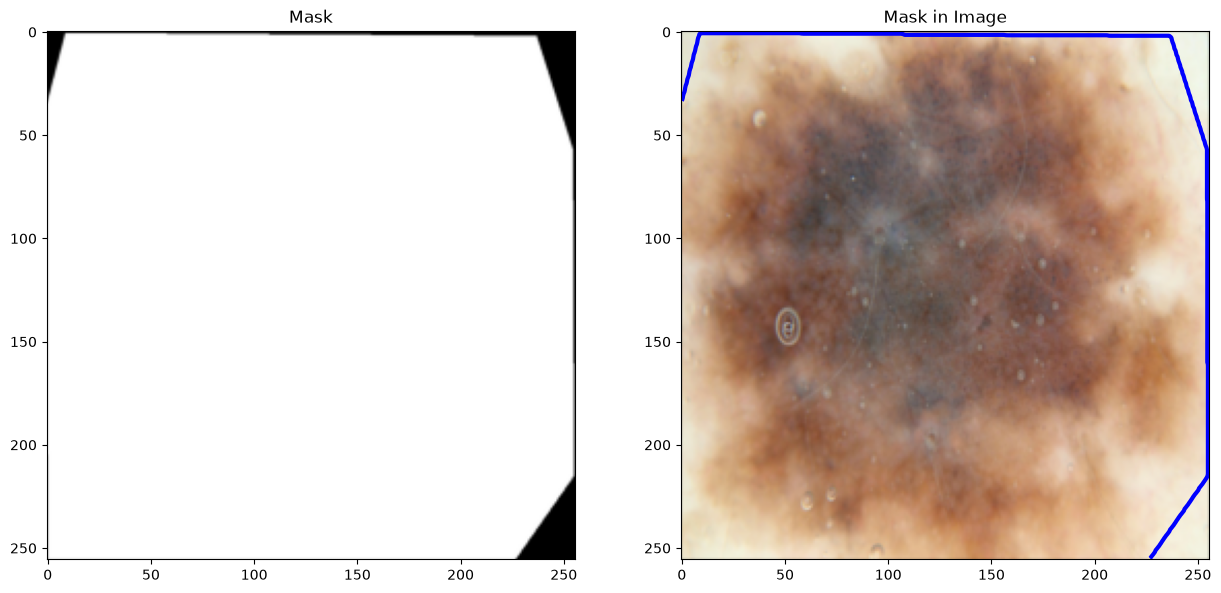

In [7]:
## Plotting Sample Data

def plot_sample_example():
    ix = random.randint(0, len(TRAINING_IMAGES))
    print(f"Random Sample Index is: {ix}")
    has_mask = TRAINING_MASKS[ix].max() > 0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 10))

    ax1.imshow(TRAINING_MASKS[ix].squeeze(), cmap = 'gray', interpolation = 'bilinear')
    ax1.set_title('Mask')

    ax2.imshow((TRAINING_IMAGES[ix]).squeeze())

    if has_mask:
        ax2.contour(TRAINING_MASKS[ix].squeeze(), colors = 'blue', linewidths = 3, levels = [0.5])
    ax2.set_title('Mask in Image')

plot_sample_example()

## Model

### Defining the model (U-net)

In [8]:
## 2D two Convolution layer block
def Conv2D_block(input_tensor, n_filters, kernel_size, batchnorm): #Function to add 2 convolutional layers
    #Convolution layer - 1
    x = Conv2D(filters=n_filters, kernel_size=(kernel_size, kernel_size), kernel_initializer='he_normal', padding='same')(input_tensor)
    #batchnormalization
    if batchnorm:
        x = BatchNormalization()(x)
    #Activation
    x = Activation('relu')(x)

    #Convolution layer - 2
    x = Conv2D(filters=n_filters, kernel_size=(kernel_size, kernel_size), kernel_initializer='he_normal', padding='same')(x)
    #batchnormalization
    if batchnorm:
        x = BatchNormalization()(x)
    #Activation
    x = Activation('relu')(x)

    return x

In [9]:
#Unet Architecture
def unet(input_image, n_filters=16, kernel_size=3, dropout=0.1, batchnorm=False):
    #Encoder Path || Contractor Path
    c1 = Conv2D_block(input_image, n_filters, kernel_size = kernel_size, batchnorm = batchnorm)
    p1 = MaxPooling2D((2,2))(c1)
    # p1 = Dropout(dropout)(p1)

    c2 = Conv2D_block(p1, n_filters * 2, kernel_size = kernel_size, batchnorm = batchnorm)
    p2 = MaxPooling2D((2, 2))(c2)
    # p2 = Dropout(dropout)(p2)

    c3 = Conv2D_block(p2, n_filters * 4, kernel_size = kernel_size, batchnorm = batchnorm)
    p3 = MaxPooling2D((2, 2))(c3)
    # p3 = Dropout(dropout)(p3)

    c4 = Conv2D_block(p3, n_filters * 8, kernel_size = kernel_size, batchnorm = batchnorm)
    p4 = MaxPooling2D((2, 2))(c4)
    # p4 = Dropout(dropout)(p4)

    c5 = Conv2D_block(p4, n_filters * 16, kernel_size = kernel_size, batchnorm = batchnorm)


    #Decoder Path  || Expansion Path
    u6 = Conv2DTranspose(n_filters * 8, (kernel_size, kernel_size), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    # u6 = Dropout(dropout)(u6)
    c6 = Conv2D_block(u6, n_filters * 8, kernel_size = kernel_size, batchnorm = batchnorm)

    u7 = Conv2DTranspose(n_filters * 4, (kernel_size, kernel_size), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    # u7 = Dropout(dropout)(u7)
    c7 = Conv2D_block(u7, n_filters * 4, kernel_size = kernel_size, batchnorm = batchnorm)

    u8 = Conv2DTranspose(n_filters * 2, (kernel_size, kernel_size), strides=(2,2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    # u8 = Dropout(dropout)(u8)
    c8 = Conv2D_block(u8, n_filters * 2, kernel_size = kernel_size, batchnorm = batchnorm)

    u9 = Conv2DTranspose(n_filters, (kernel_size, kernel_size), strides=(2,2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    # u9 = Dropout(dropout)(u9)
    c9 = Conv2D_block(u9, n_filters, kernel_size = kernel_size, batchnorm = batchnorm)

    #final 1*1 Convolutional layer
    output = Conv2D(1, (1,1), activation='sigmoid')(c9)
    model = Model(inputs=[input_image], outputs=[output])
    return model

### Defining the metrics

In [10]:
def dice_coef(y_true, y_pred, smooth=1):
  y_true_f = K.flatten(y_true)
  y_pred_f = K.flatten(y_pred)
  intersection = K.sum(y_true_f * y_pred_f)

  return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def iou(y_true, y_pred): #Jaccard
  y_true_f = K.flatten(y_true)
  y_pred_f = K.flatten(y_pred)
  intersection = K.sum(y_true_f * y_pred_f)
  union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

  return intersection/union

def specificity(y_true, y_pred):
  true_negatives = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
  possible_negatives = K.sum(K.round(K.clip(1 - y_true, 0, 1)))

  return true_negatives / (possible_negatives + K.epsilon())

## Training

### Dataset Partitioning for Training and Testing

In [11]:
#Instantiate Keras tensor
input_img = Input((IM_HEIGHT, IM_WIDTH, 3), name='img')
metrics=[Accuracy(), Precision(), Recall(), iou, specificity, dice_coef]

#initialize params
num_filters = 16 #32
kernel_size = 5
dropout = 0.1
batch_size = 16 #32
epochs = 400
optimizer = Adam()

#CallBacks
call_backs = [
    #EarlyStopping(patience=10, verbose=1), #prevents overfitting or unnecessary training
    ReduceLROnPlateau(factor=0.1, patience=5, min_lr=0.00001, verbose=1),
    ModelCheckpoint(
        f'/home/antoniovinicius/projects/skin_cancer/assets/checkpoint/unet_segmentation_{num_filters}_{kernel_size}_{batch_size}_{epochs}.weights.h5', 
        verbose=1, 
        save_best_only=True, 
        save_weights_only=True
    ) #saves the model
]

I0000 00:00:1790034378.711976 3075660 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 26782 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:17:00.0, compute capability: 7.0
I0000 00:00:1790034378.712551 3075660 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13350 MB memory:  -> device: 1, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:65:00.0, compute capability: 7.0


In [12]:
X_train, X_val, y_train, y_val = train_test_split(TRAINING_IMAGES, TRAINING_MASKS, test_size=0.2)

start = datetime.now()

# create model
model = unet(input_img, n_filters=num_filters, kernel_size=kernel_size, dropout=dropout)

# # Compile model
# model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=metrics)

# # Fit the model
# results = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, callbacks=call_backs, validation_data=(X_val, y_val))

# K.clear_session()
# gc.collect()

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K

# =====================================================================
# 1. DEFINIÇÃO DA FUNÇÃO DE PERDA (BCE + Dice Loss)
# Força o modelo a focar nas bordas e no formato da lesão
# =====================================================================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(tf.cast(y_true, tf.float32), y_pred)
    dice = 1.0 - dice_coef(y_true, y_pred)
    return bce + dice

# =====================================================================
# 2. DATA AUGMENTATION MÚLTIPLO
# Cria variações em tempo real para evitar Overfitting
# =====================================================================
# Dicionário de transformações (faz sentido para lesões de pele)
data_gen_args = dict(
    rotation_range=45,       # Rotaciona até 45 graus
    width_shift_range=0.1,   # Move horizontalmente 10%
    height_shift_range=0.1,  # Move verticalmente 10%
    zoom_range=0.15,         # Zoom in/out de 15%
    horizontal_flip=True,    # Espelhamento horizontal
    vertical_flip=True,      # Espelhamento vertical
    fill_mode='reflect'      # Preenchimento inteligente das bordas
)

image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

# O SEGREDO AQUI: Usar a mesma seed para que imagem e máscara sofram a mesma transformação!
seed = 42
batch_size = 16

# Geradores que puxam direto dos arrays em memória
image_generator = image_datagen.flow(TRAINING_IMAGES, batch_size=batch_size, seed=seed)
mask_generator = mask_datagen.flow(TRAINING_MASKS, batch_size=batch_size, seed=seed)

# Função para juntar imagens e máscaras no formato exigido pelo Keras
def train_generator(img_gen, msk_gen):
    for (img, msk) in zip(img_gen, msk_gen):
        yield (img, msk)

# =====================================================================
# 3. CALLBACKS INTELIGENTES
# =====================================================================
callbacks_list = [
    # Salva APENAS os pesos que tiveram o menor erro de validação
    ModelCheckpoint('melhor_unet_isic2018.keras', monitor='val_loss', verbose=1, save_best_only=True),
    
    # Se a validação não melhorar por 8 épocas, diminui a taxa de aprendizado pela metade
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
    
    # Se a validação não melhorar por 15 épocas, aborta o treinamento para não gastar GPU à toa
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
]

# =====================================================================
# 4. COMPILAÇÃO E TREINAMENTO
# =====================================================================
# Compilando com uma taxa de aprendizado ligeiramente menor para refinar melhor
model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss=bce_dice_loss, 
              metrics=['accuracy', dice_coef])

epochs = 100 # Pode colocar alto, o EarlyStopping vai parar quando for a hora certa
steps_per_epoch = len(TRAINING_IMAGES) // batch_size

print("Iniciando o treinamento aprimorado...")
history = model.fit(
    train_generator(image_generator, mask_generator),
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=(VALIDATION_IMAGES, VALIDATION_MASKS),
    callbacks=callbacks_list,
    verbose=1
)

Iniciando o treinamento aprimorado...


/home/antoniovinicius/projects/skin_cancer/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a generator. The generator is expected to yield already-shuffled data.
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/100


I0000 00:00:1790034381.258849 3075660 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1790034385.178743 3075937 service.cc:153] XLA service 0x74d73804a370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790034385.178797 3075937 service.cc:161]   StreamExecutor [0]: Tesla V100S-PCIE-32GB, Compute Capability 7.0 (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1790034385.178817 3075937 service.cc:161]   StreamExecutor [1]: Tesla V100S-PCIE-32GB, Compute Capability 7.0 (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1790034385.400766 3075937 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790034386.378254 3075937 cuda_dnn.cc:461] Loaded cuDNN version 91002


  2/162 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.0089 - dice_coef: 0.3053 - loss: 1.6093   

I0000 00:00:1790034404.175138 3075937 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7157 - dice_coef: 0.5362 - loss: 0.8378
Epoch 1: val_loss improved from None to 0.69049, saving model to melhor_unet_isic2018.keras

Epoch 1: finished saving model to melhor_unet_isic2018.keras
162/162 ━━━━━━━━━━━━━━━━━━━━ 69s 287ms/step - accuracy: 0.7157 - dice_coef: 0.5362 - loss: 0.8378 - val_accuracy: 0.6606 - val_dice_coef: 0.6546 - val_loss: 0.6905 - learning_rate: 1.0000e-04
Epoch 2/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7427 - dice_coef: 0.6928 - loss: 0.5833
Epoch 2: val_loss improved from 0.69049 to 0.65001, saving model to melhor_unet_isic2018.keras

Epoch 2: finished saving model to melhor_unet_isic2018.keras
162/162 ━━━━━━━━━━━━━━━━━━━━ 50s 228ms/step - accuracy: 0.7427 - dice_coef: 0.6928 - loss: 0.5833 - val_accuracy: 0.7109 - val_dice_coef: 0.7101 - val_loss: 0.6500 - learning_rate: 1.0000e-04
Epoch 3/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7436 - dice_coef: 0.7210 - los

### K-Fold Cross-Validation

In [13]:
# #@title
# # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# # kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=7) https://machinelearningmastery.com/evaluate-performance-deep-learning-models-keras/

# kf = KFold(n_splits = 5)

# loss_scores = []
# precision_scores = []
# iou_scores = []
# recall_scores = []
# specificity_score = []
# dice_coef_scores = []

# for train_idx, val_idx in list(kf.split(TRAINING_IMAGES, TRAINING_MASKS)):
#   X_train, X_val = TRAINING_IMAGES[train_idx], TRAINING_IMAGES[val_idx]
#   y_train, y_val = TRAINING_MASKS[train_idx], TRAINING_MASKS[val_idx]

#   # create model
#   model = unet(input_img, n_filters=n_filters, kernel_size=kernel_size, dropout=dropout, batchnorm=True)

#   # Compile model
#   model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=metrics)

#   # Fit the model
#   results = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, callbacks=call_backs, validation_data=(X_val, y_val))

#   loss = (results.history['loss'][-1])
#   precision = (results.history['precision'][-1])
#   recall = (results.history['recall'][-1])
#   iou = (results.history['iou'][-1])
#   specificity = (results.history['specificity'][-1])
#   dice_coef = (results.history['dice_coef'][-1])

#   print(f"loss: {loss}")
#   print(f"precision: {precision}")
#   print(f"recall: {recall}")
#   print(f"iou: {iou}")
#   print(f"specificity: {specificity}")
#   print(f"dice_coef: {dice_coef}")

#   loss_scores.append(loss)
#   precision_scores.append(precision)
#   recall_scores.append(recall)
#   iou_scores.append(iou)
#   specificity_score.append(specificity)
#   dice_coef_scores.append(dice_coef)

#   K.clear_session()
#   gc.collect()

#   del model
#   del X_train
#   del X_val
#   del y_train
#   del y_val
#   del results
#   del train_idx
#   del val_idx

# print(f"{np.mean(loss_scores)} (+/- {np.std(loss_scores)})")
# print(f"{np.mean(precision_scores)} (+/- {np.std(precision_scores)})")
# print(f"{np.mean(recall_scores)} (+/- {np.std(recall_scores)})")
# print(f"{np.mean(iou_scores)} (+/- {np.std(iou_scores)})")
# print(f"{np.mean(specificity_score)} (+/- {np.std(specificity_score)})")
# print(f"{np.mean(dice_coef_scores)} (+/- {np.std(dice_coef_scores)})")

In [14]:
K.clear_session()
gc.collect()

0

In [15]:
model.evaluate(VALIDATION_IMAGES, VALIDATION_MASKS, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6892 - dice_coef: 0.7669 - loss: 0.4930


[0.49301016330718994, 0.689194917678833, 0.7669312953948975]

In [16]:
# np.sum([np.prod(v.get_shape().as_list()) for v in model.trainable_variables])

In [17]:
preds_val = model.predict(TRAINING_IMAGES, verbose=1)
preds_val_t = (preds_val > 0.75).astype(np.uint8)

82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step


In [18]:
def plot_sample_results(X, y, preds, binary_preds, has_mask):
    ix = random.randint(0, len(X))
    # ix = 84
    # ix = 0

    print(f"ix: {ix}")

    fig, ax = plt.subplots(1, 4, figsize=(20,10))

    ax[0].imshow(X[ix])
    if has_mask:
        ax[0].contour(y[ix].squeeze(), colors='b', levels=[0.5])
    ax[0].set_title('real mask')

    ax[1].imshow(preds[ix].squeeze(), vmin=0, vmax=1)
    if has_mask:
        ax[1].contour(y[ix].squeeze(), colors='b', levels=[0.5])
    ax[1].set_title('cancer Predicted')

    ax[2].imshow(binary_preds[ix].squeeze(), vmin=0, vmax=1)
    if has_mask:
        ax[2].contour(y[ix].squeeze(), colors='b', levels=[0.5])
    ax[2].set_title('cancer Predicted Binary')

    ax[3].imshow(X[ix])
    if has_mask:
        ax[3].contour(y[ix].squeeze(), colors='#00FF00', levels=[0.5])
    ax[3].contour(binary_preds[ix].squeeze(), colors='r', levels=[0.5])
    ax[3].set_title('cancer')

ix: 338


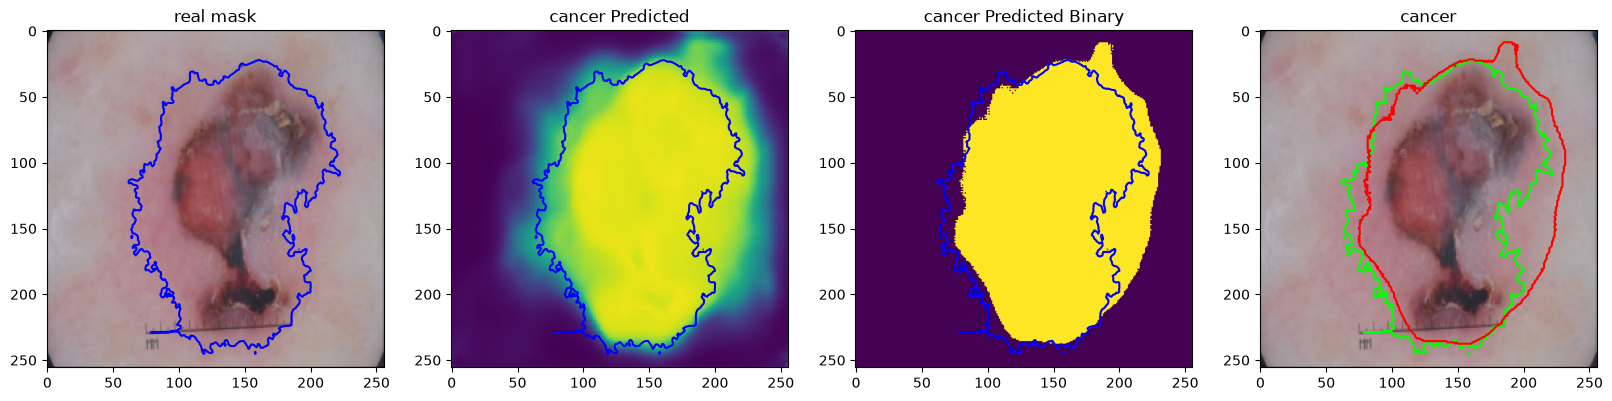

In [19]:
## Predictions on Test Set 62
plot_sample_results(X=TRAINING_IMAGES, y=TRAINING_MASKS, preds=preds_val, binary_preds=preds_val_t, has_mask=True)

ix: 52


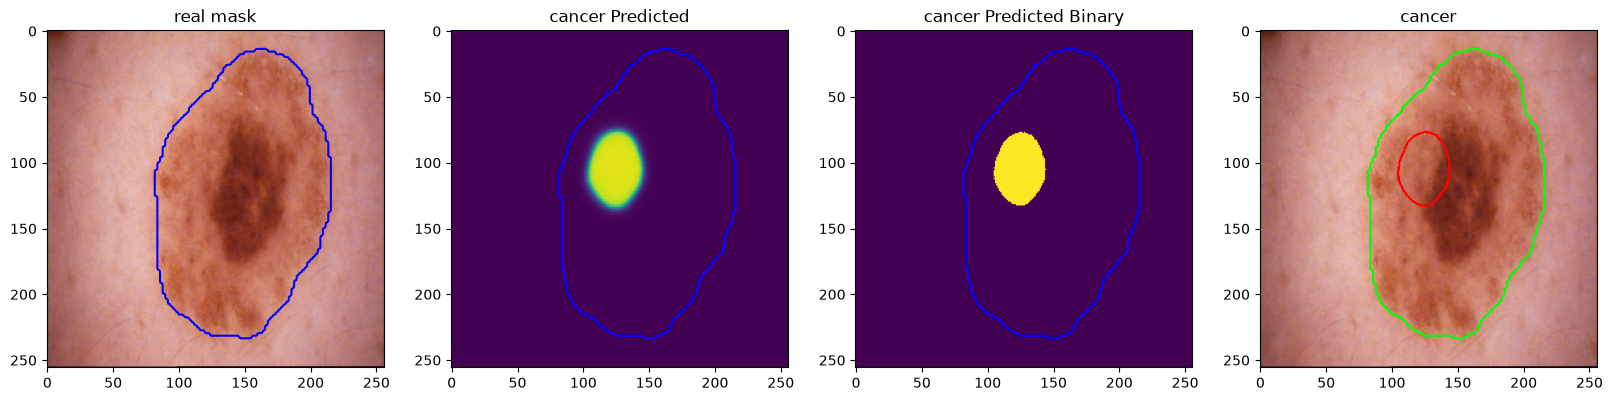

In [20]:
plot_sample_results(X=VALIDATION_IMAGES, y=VALIDATION_MASKS, preds=preds_val, binary_preds=preds_val_t, has_mask=True)

## Results

In [21]:
#Unet Jaccard
def plot_history(results):
    plt.figure(figsize=(8,8))
    plt.title("Jaccard Vs Epochs")
    plt.plot(results.history["iou"], label="iou")
    plt.plot(results.history["val_iou"], label="val_iou")
    plt.plot( np.argmax(results.history["val_iou"]), np.max(results.history["val_iou"]), marker="x", color="r", label="best model")
    plt.xlabel("Epochs")
    plt.ylabel("Jaccard")
    plt.legend()

plot_history(results)
print(results.history["iou"])

NameError: name 'results' is not defined

[0.3766202926635742, 0.34039804339408875, 0.3230430781841278, 0.3192415237426758, 0.29127955436706543, 0.270974338054657, 0.24879276752471924, 0.22329607605934143, 0.21414601802825928, 0.2080397754907608, 0.204681396484375, 0.20292285084724426, 0.1947927474975586, 0.19002372026443481, 0.1984957605600357, 0.19099631905555725, 0.19114458560943604, 0.18419834971427917, 0.18618206679821014, 0.18923313915729523, 0.1745384782552719, 0.18419168889522552, 0.16940373182296753, 0.1644027978181839, 0.16684293746948242, 0.15760429203510284, 0.1526234894990921, 0.15054357051849365, 0.17102544009685516, 0.15280218422412872, 0.1380189210176468, 0.13422605395317078, 0.13235889375209808, 0.1310536414384842, 0.1294884830713272, 0.12796615064144135, 0.12777091562747955, 0.12760205566883087, 0.12745119631290436, 0.12730039656162262, 0.1271532028913498, 0.12701351940631866, 0.1268746256828308, 0.1267261952161789, 0.12658727169036865, 0.12640929222106934, 0.12628254294395447, 0.12612342834472656, 0.12598182

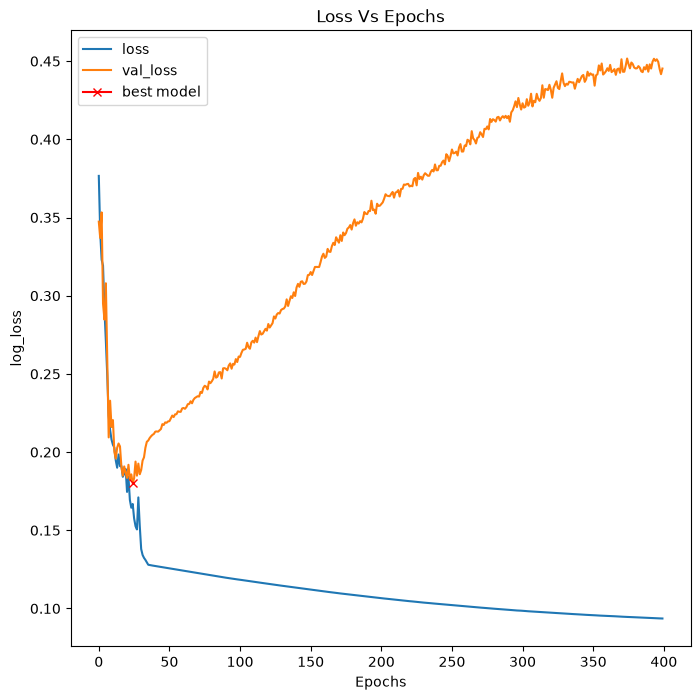

In [ ]:
#Unet loss
def plot_history(results):
    plt.figure(figsize=(8,8))
    plt.title("Loss Vs Epochs")
    plt.plot(results.history["loss"], label="loss")
    plt.plot(results.history["val_loss"], label="val_loss")
    plt.plot( np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
    plt.xlabel("Epochs")
    plt.ylabel("log_loss")
    plt.legend()

plot_history(results)
print(results.history["loss"])

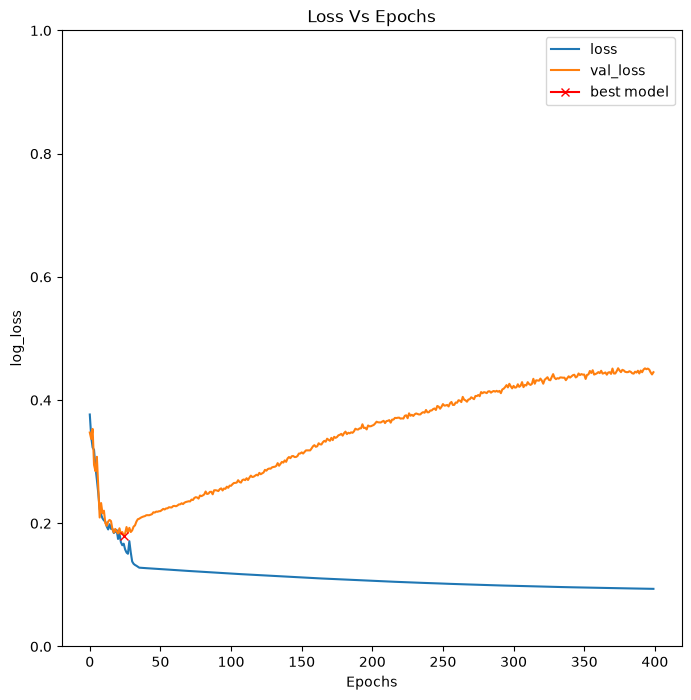

In [ ]:
#Unet loss
def plot_history(results):
    plt.figure(figsize=(8,8))
    plt.title("Loss Vs Epochs")
    plt.plot(results.history["loss"], label="loss")
    plt.plot(results.history["val_loss"], label="val_loss")
    plt.plot( np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
    plt.ylim([0, 1])
    plt.xlabel("Epochs")
    plt.ylabel("log_loss")
    plt.legend()

plot_history(results)

In [ ]:
print(results.history.keys())

dict_keys(['accuracy', 'dice_coef', 'iou', 'loss', 'precision_1', 'recall_1', 'specificity', 'val_accuracy', 'val_dice_coef', 'val_iou', 'val_loss', 'val_precision_1', 'val_recall_1', 'val_specificity', 'learning_rate'])


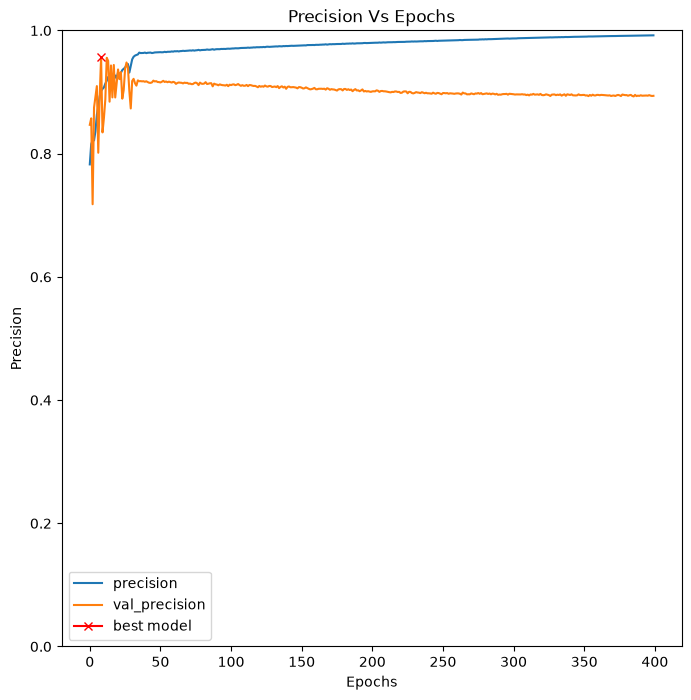

[0.7826191782951355, 0.8156524896621704, 0.8216592073440552, 0.8215293288230896, 0.8364292979240417, 0.8633601069450378, 0.8766669034957886, 0.8930696249008179, 0.9018880724906921, 0.905160129070282, 0.9076297879219055, 0.9138421416282654, 0.9183871150016785, 0.924621045589447, 0.9187145829200745, 0.9173423051834106, 0.9172118306159973, 0.9221964478492737, 0.9269916415214539, 0.9220105409622192, 0.9321730136871338, 0.9219553470611572, 0.9311925172805786, 0.9357694387435913, 0.937721312046051, 0.9398677945137024, 0.9441090226173401, 0.9455113410949707, 0.9316272139549255, 0.9419894218444824, 0.9531387686729431, 0.9573303461074829, 0.9592505097389221, 0.9602937698364258, 0.9610623717308044, 0.9641060829162598, 0.9633644819259644, 0.9634248614311218, 0.9635345339775085, 0.9641409516334534, 0.9632601737976074, 0.9638547897338867, 0.9640026688575745, 0.9641537666320801, 0.9633814692497253, 0.9637845754623413, 0.9643709063529968, 0.9644783139228821, 0.964545488357544, 0.9648186564445496, 0.9

In [ ]:
#Unet Precision
def plot_history(results):
    plt.figure(figsize=(8,8))
    plt.title("Precision Vs Epochs")
    plt.plot(results.history["precision_1"], label="precision")
    plt.plot(results.history["val_precision_1"], label="val_precision")
    plt.plot(np.argmax(results.history["val_precision_1"]), np.max(results.history["val_precision_1"]), marker="x", color="r", label="best model")
    plt.ylim([0, 1])
    plt.xlabel("Epochs")
    plt.ylabel("Precision")
    plt.legend()
    plt.show() # Adicionado para exibir o gráfico corretamente no notebook

plot_history(results)
print(results.history["precision_1"])

[0.9707232117652893, 0.9688880443572998, 0.9664437770843506, 0.9647557139396667, 0.9624599814414978, 0.9665365815162659, 0.9678348302841187, 0.9700207114219666, 0.972050130367279, 0.972577691078186, 0.972952127456665, 0.9743454456329346, 0.9755067229270935, 0.9766407012939453, 0.9757980108261108, 0.9744082093238831, 0.9744549989700317, 0.9759514331817627, 0.9771091341972351, 0.9760961532592773, 0.9780725240707397, 0.9756304025650024, 0.9772377610206604, 0.9782451391220093, 0.9790513515472412, 0.9791268110275269, 0.9801576137542725, 0.9805933237075806, 0.9776129126548767, 0.9795315861701965, 0.9819738268852234, 0.9833827018737793, 0.9838660359382629, 0.984103798866272, 0.9841424226760864, 0.985161542892456, 0.984828531742096, 0.9848375916481018, 0.9848830103874207, 0.9850885272026062, 0.9848043322563171, 0.9849787950515747, 0.9849576354026794, 0.985053539276123, 0.9847219586372375, 0.984842836856842, 0.9851837158203125, 0.9851126074790955, 0.9851372241973877, 0.9852578043937683, 0.98518

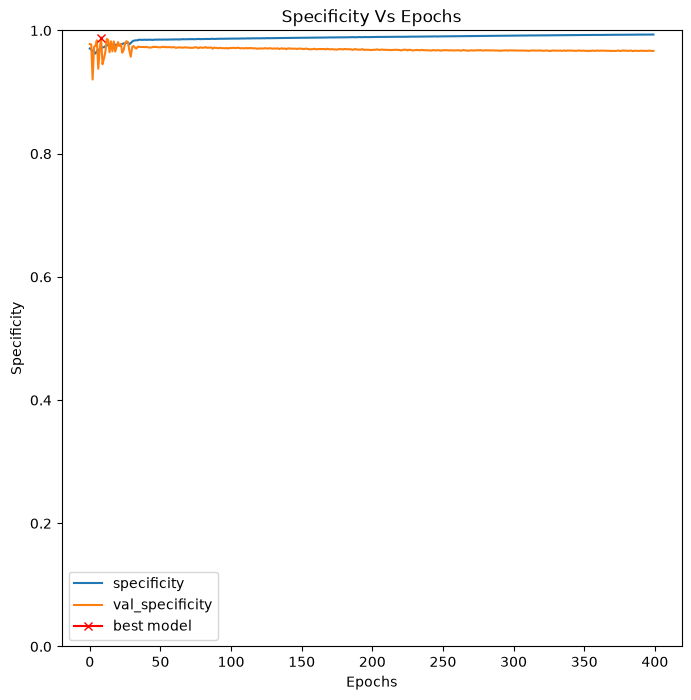

In [ ]:
# Unet Specificity
def plot_history(results):
    plt.figure(figsize=(8,8))
    plt.title("Specificity Vs Epochs")
    plt.plot(results.history["specificity"], label="specificity")
    plt.plot(results.history["val_specificity"], label="val_specificity")
    plt.plot(np.argmax(results.history["val_specificity"]), np.max(results.history["val_specificity"]), marker="x", color="r", label="best model")
    plt.ylim([0, 1])
    plt.xlabel("Epochs")
    plt.ylabel("Specificity")
    plt.legend()

plot_history(results)
print(results.history["specificity"])

[0.3749414384365082, 0.4391358196735382, 0.4730861783027649, 0.4832906723022461, 0.5336912870407104, 0.5676715970039368, 0.6060523390769958, 0.6392189264297485, 0.6561750769615173, 0.6662998199462891, 0.6722920536994934, 0.6747991442680359, 0.6855899691581726, 0.6945310831069946, 0.6800467371940613, 0.6909604668617249, 0.6927428841590881, 0.7002624273300171, 0.7037841081619263, 0.695177435874939, 0.7185976505279541, 0.6986814141273499, 0.7243221998214722, 0.7325352430343628, 0.7292147278785706, 0.7430691123008728, 0.7511573433876038, 0.7529585957527161, 0.7235713005065918, 0.7498955130577087, 0.7736614346504211, 0.7783874869346619, 0.7832455635070801, 0.7847834229469299, 0.7881391644477844, 0.7900291085243225, 0.7904596924781799, 0.7915177941322327, 0.7911024689674377, 0.7904910445213318, 0.792229175567627, 0.7925626039505005, 0.7924342751502991, 0.7919213175773621, 0.7930020689964294, 0.7922916412353516, 0.7934799790382385, 0.7931393980979919, 0.7942009568214417, 0.7932352423667908, 0

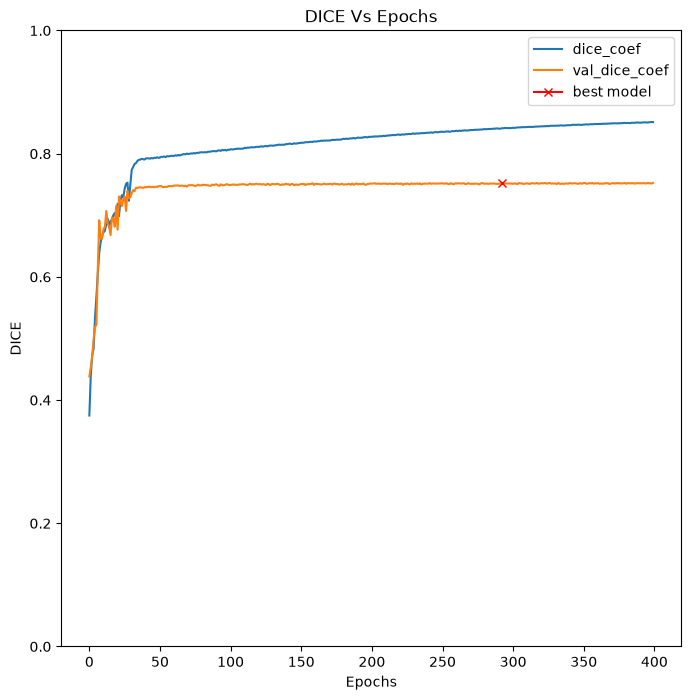

In [ ]:
#Unet DICE
def plot_history(results):
    plt.figure(figsize=(8,8))
    plt.title("DICE Vs Epochs")
    plt.plot(results.history["dice_coef"], label="dice_coef")
    plt.plot(results.history["val_dice_coef"], label="val_dice_coef")
    plt.plot(np.argmax(results.history["val_dice_coef"]), np.max(results.history["val_dice_coef"]), marker="x", color="r", label="best model")
    plt.ylim([0, 1])
    plt.xlabel("Epochs")
    plt.ylabel("DICE")
    plt.legend()

plot_history(results)
print(results.history["dice_coef"])

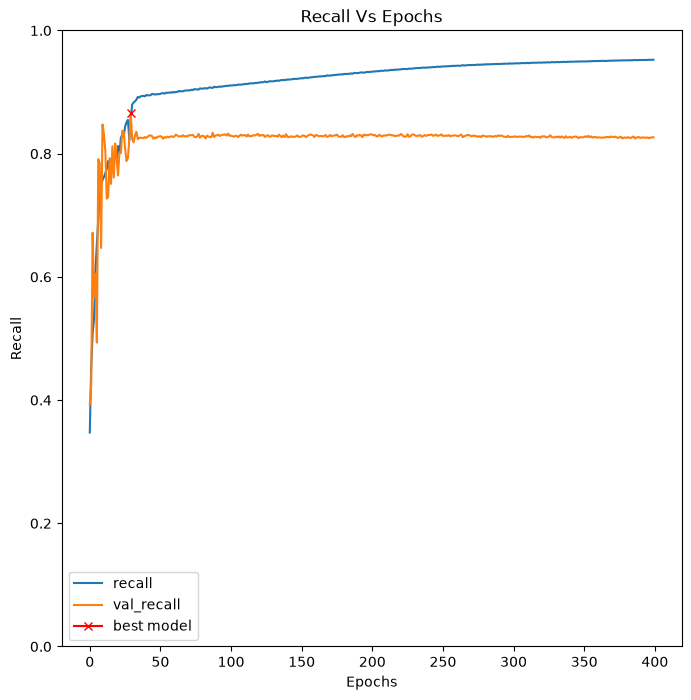

[0.34737899899482727, 0.45294350385665894, 0.5081477165222168, 0.5319535732269287, 0.6092493534088135, 0.6540560126304626, 0.6924431920051575, 0.7361109852790833, 0.7501382231712341, 0.7571351528167725, 0.7620844841003418, 0.7683365345001221, 0.7752877473831177, 0.7880172729492188, 0.7666357159614563, 0.7904718518257141, 0.7943801879882812, 0.793931782245636, 0.7985498309135437, 0.792213499546051, 0.812419593334198, 0.8008008003234863, 0.8257395625114441, 0.831076443195343, 0.8275779485702515, 0.8440829515457153, 0.8511491417884827, 0.8547747135162354, 0.8219757080078125, 0.8570083975791931, 0.8799014687538147, 0.8830989599227905, 0.884971022605896, 0.8877641558647156, 0.8921076059341431, 0.8910863399505615, 0.8931533694267273, 0.8935556411743164, 0.8939149975776672, 0.8930971622467041, 0.8952928781509399, 0.8946791291236877, 0.8947264552116394, 0.8948888778686523, 0.896992564201355, 0.8966782689094543, 0.8960247039794922, 0.896311342716217, 0.896614670753479, 0.8966616988182068, 0.897

In [ ]:
#Unet Recall
def plot_history(results):
    plt.figure(figsize=(8,8))
    plt.title("Recall Vs Epochs")
    plt.plot(results.history["recall_1"], label="recall")
    plt.plot(results.history["val_recall_1"], label="val_recall")
    plt.plot(np.argmax(results.history["val_recall_1"]), np.max(results.history["val_recall_1"]), marker="x", color="r", label="best model")
    plt.ylim([0, 1])
    plt.xlabel("Epochs")
    plt.ylabel("Recall")
    plt.legend()
    plt.show()

plot_history(results)
print(results.history["recall_1"])

Gerando predições no conjunto de validação...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step

   MÉTRICAS MÉDIAS GLOBAIS - CONJUNTO DE VALIDAÇÃO   
Jaccard Médio (IoU): 0.7736
Dice Médio:          0.8615
Precisão Média:      0.8381
Recall Médio:        0.9213



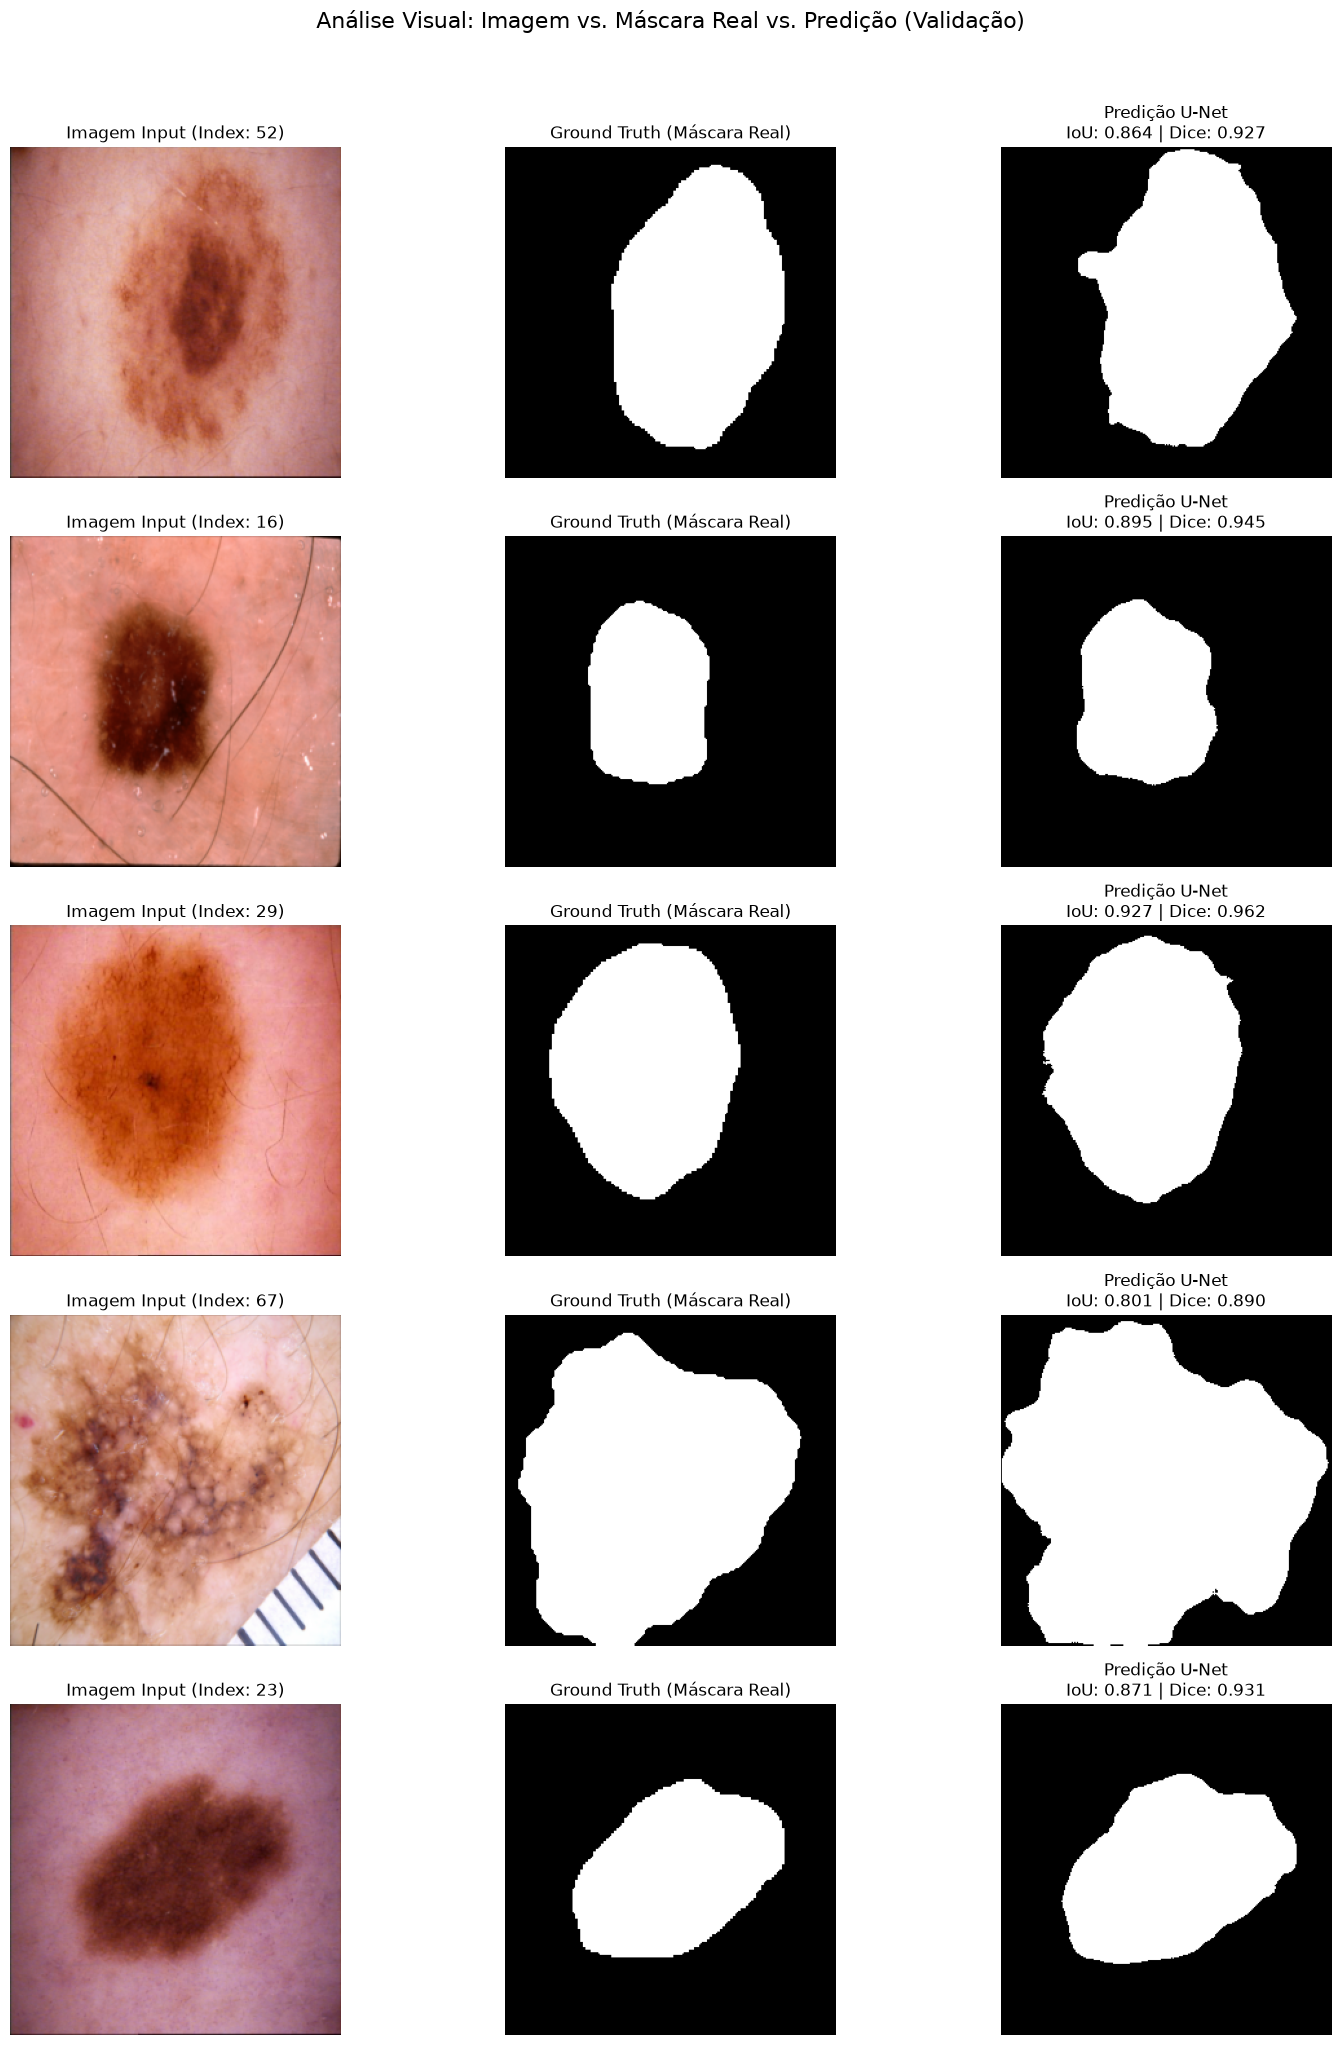

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Funções matemáticas para cálculo das métricas de segmentação
def calculate_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

def calculate_dice(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    # Adicionamos um pequeno epsilon (1e-6) para evitar divisão por zero
    return (2. * intersection) / (y_true.sum() + y_pred.sum() + 1e-6)

print("Gerando predições no conjunto de validação...")
# ATENÇÃO: Substitua 'model' abaixo pelo nome da variável do seu modelo instanciado/treinado
preds_val = model.predict(VALIDATION_IMAGES, verbose=1)

# Binarizando as predições e as máscaras reais (threshold de 0.5)
preds_val_bin = (preds_val > 0.5).astype(np.uint8)
masks_val_bin = (VALIDATION_MASKS > 0.5).astype(np.uint8)

ious, dices, precisions, recalls = [], [], [], []

# Calculando métricas imagem por imagem
for idx in range(len(VALIDATION_IMAGES)):
    y_t = masks_val_bin[idx].flatten()
    y_p = preds_val_bin[idx].flatten()
    
    ious.append(calculate_iou(y_t, y_p))
    dices.append(calculate_dice(y_t, y_p))
    
    # Previne warnings do sklearn em imagens sem lesão (tudo 0)
    if y_t.sum() > 0 or y_p.sum() > 0:
        precisions.append(precision_score(y_t, y_p, zero_division=0))
        recalls.append(recall_score(y_t, y_p, zero_division=0))

print("\n" + "="*50)
print("   MÉTRICAS MÉDIAS GLOBAIS - CONJUNTO DE VALIDAÇÃO   ")
print("="*50)
print(f"Jaccard Médio (IoU): {np.mean(ious):.4f}")
print(f"Dice Médio:          {np.mean(dices):.4f}")
print(f"Precisão Média:      {np.mean(precisions):.4f}")
print(f"Recall Médio:        {np.mean(recalls):.4f}")
print("="*50 + "\n")

# Escolhendo 5 índices aleatórios para plotar os resultados
num_samples = 5
indices = np.random.choice(len(VALIDATION_IMAGES), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 3, figsize=(16, 4 * num_samples))
fig.suptitle('Análise Visual: Imagem vs. Máscara Real vs. Predição (Validação)', fontsize=16, y=1.02)

for i, idx in enumerate(indices):
    # 1. Plot Imagem Original
    ax_img = axes[i, 0]
    img = VALIDATION_IMAGES[idx]
    if img.dtype != np.uint8 and img.max() > 1.0: 
        img = img / 255.0
    ax_img.imshow(img)
    ax_img.set_title(f"Imagem Input (Index: {idx})")
    ax_img.axis('off')
    
    # 2. Plot Máscara Real (Ground Truth)
    ax_gt = axes[i, 1]
    ax_gt.imshow(np.squeeze(masks_val_bin[idx]), cmap='gray')
    ax_gt.set_title("Ground Truth (Máscara Real)")
    ax_gt.axis('off')
    
    # 3. Plot Predição da U-Net
    ax_pred = axes[i, 2]
    ax_pred.imshow(np.squeeze(preds_val_bin[idx]), cmap='gray')
    ax_pred.set_title(f"Predição U-Net\nIoU: {ious[idx]:.3f} | Dice: {dices[idx]:.3f}")
    ax_pred.axis('off')

plt.tight_layout()
plt.show()

In [22]:
import numpy as np

def calcular_metricas_segmentacao(y_true, y_pred, threshold=0.5):
    # Binarizar as predições
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    y_true_bin = y_true.astype(np.float32)
    
    # Achatar os arrays para calcular globalmente
    y_true_f = y_true_bin.flatten()
    y_pred_f = y_pred_bin.flatten()
    
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    
    # Métricas
    iou = (intersection + 1e-7) / (union + 1e-7)
    dice = (2. * intersection + 1e-7) / (np.sum(y_true_f) + np.sum(y_pred_f) + 1e-7)
    
    tp = intersection
    fp = np.sum(y_pred_f) - tp
    fn = np.sum(y_true_f) - tp
    
    precision = (tp + 1e-7) / (tp + fp + 1e-7)
    recall = (tp + 1e-7) / (tp + fn + 1e-7)
    
    return {
        "Jaccard Index (IoU)": iou,
        "Dice Score (DSC)": dice,
        "Precision": precision,
        "Recall": recall
    }

# Calculando para o dataset de validação
preds = model.predict(VALIDATION_IMAGES)
metricas = calcular_metricas_segmentacao(VALIDATION_MASKS, preds)

print("==== RESULTADOS DA VALIDAÇÃO (U-NET) ====")
for metrica, valor in metricas.items():
    print(f"{metrica}: {valor:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 353ms/step
==== RESULTADOS DA VALIDAÇÃO (U-NET) ====
Jaccard Index (IoU): 0.6845
Dice Score (DSC): 0.8127
Precision: 0.7535
Recall: 0.8819
